In [172]:
!uv pip install numpy pandas yfinance matplotlib seaborn plotly

Using Python 3.13.5 environment at: /home/michabay/projects/trading-bot/.venv
Audited 6 packages in 4ms


In [173]:
# Source: https://www.youtube.com/watch?v=A2NUo93MyH0&t=5s
from datetime import datetime
from zoneinfo import ZoneInfo

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [174]:
def fix_yf_df(yf_df: pd.DataFrame) -> pd.DataFrame:
    # Transform to long format: Date and Ticker as columns, single-level headers
    df = yf_df.stack(future_stack=True, level=0).rename_axis(["Date", "symbols"])
    # Remove the 'Price' name from the columns index
    df.columns.name = None

    if isinstance(df, pd.Series):
        raise TypeError(f"df is of type {type(df)} instead of pd.DataFrame")

    df.sort_values(["symbols", "Date"], inplace=True)
    df.reset_index(inplace=True)
    zi = ZoneInfo("US/Eastern")
    df["Date"] = df["Date"].apply(
        lambda x: datetime.fromisoformat(str(x)).astimezone(zi)
    )

    if "Adj Close" in df.columns:
        del df["Adj Close"]

    df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }, inplace=True)

    return df.set_index("Date")

In [175]:
# Get the stock data
df = yf.download(
    "TGT", group_by="Ticker", start="2013-01-01",
    end="2025-08-18", auto_adjust=True
)

data = fix_yf_df(df)

[*********************100%***********************]  1 of 1 completed


### Mean Reversion Strategy

In [176]:
data["returns"] = np.log(data["close"] / data["close"].shift(1))
data["returns"]

Date
2013-01-02 00:00:00-05:00         NaN
2013-01-03 00:00:00-05:00    0.022526
2013-01-04 00:00:00-05:00    0.006957
2013-01-07 00:00:00-05:00    0.011815
2013-01-08 00:00:00-05:00   -0.010825
                               ...   
2025-08-11 00:00:00-04:00   -0.013276
2025-08-12 00:00:00-04:00    0.021402
2025-08-13 00:00:00-04:00    0.002280
2025-08-14 00:00:00-04:00   -0.010591
2025-08-15 00:00:00-04:00   -0.011869
Name: returns, Length: 3175, dtype: float64

In [177]:
# Defining a trend path
SMA = 25

In [178]:
data["SMA"] = data["close"].rolling(SMA).mean()

In [179]:
# Setting a threshold for signal to open long or short
threshold = 2

In [180]:
data["distance"] = data["close"] - data["SMA"]

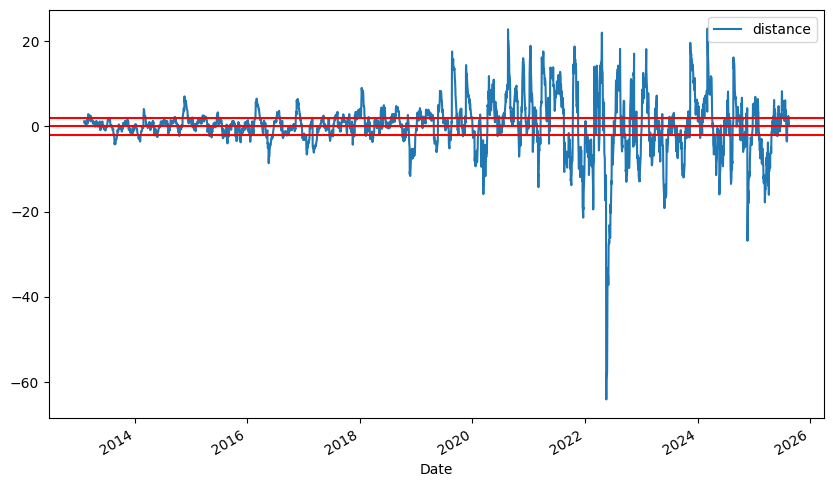

In [181]:
data["distance"].dropna().plot(figsize=(10, 6), legend=True)
plt.axhline(threshold, color='r')
plt.axhline(-threshold, color='r')
plt.axhline(0, color='r')

In [182]:
# When trend line is greater than upper threshold --> short
data["position"] = np.where(data["distance"] > threshold, -1, np.nan)

In [183]:
# When trend is less than lower threshold --> long
data["position"] = np.where(data["distance"] < -threshold, 1, data["position"])

In [184]:
# When trend cross back into threshold area --> close position (go neutral)
data["position"] = np.where(
    data["distance"] * data["distance"].shift(1) < 0, 0, data["position"]
)

In [185]:
# Fill NA's with 0
data["position"] = data["position"].ffill().fillna(0)

<Axes: xlabel='Date'>

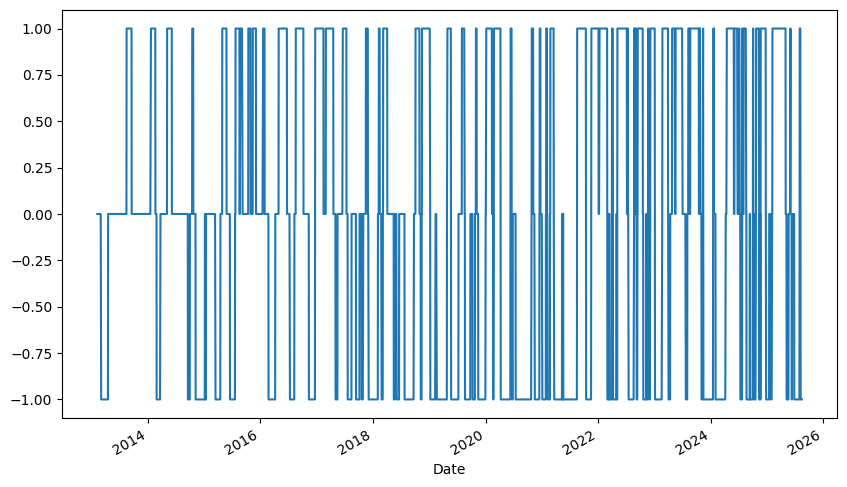

In [186]:
# Plot
data["position"].iloc[SMA:].plot(ylim=[-1.1, 1.1], figsize=(10, 6))

In [187]:
data["strategy"] = data["position"].shift(1) * data["returns"]

### Mean Reversion Results

<Axes: xlabel='Date'>

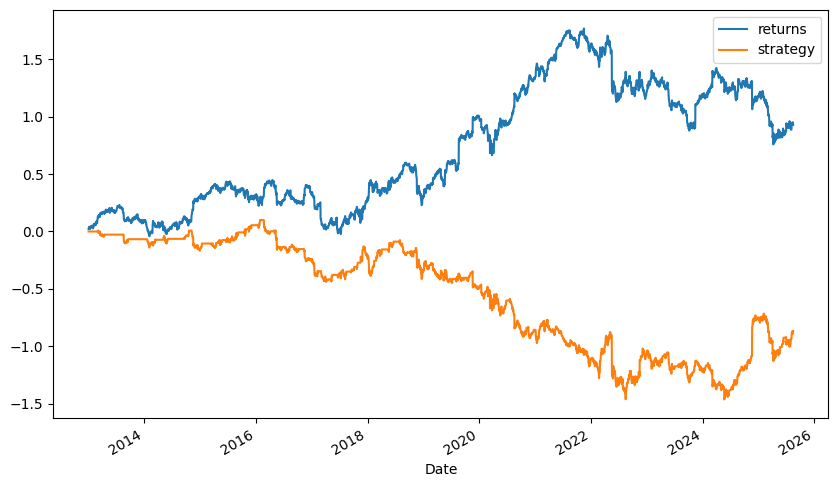

In [188]:
data[["returns", "strategy"]].dropna().cumsum().plot(figsize=(10, 6))

<Axes: xlabel='Date'>

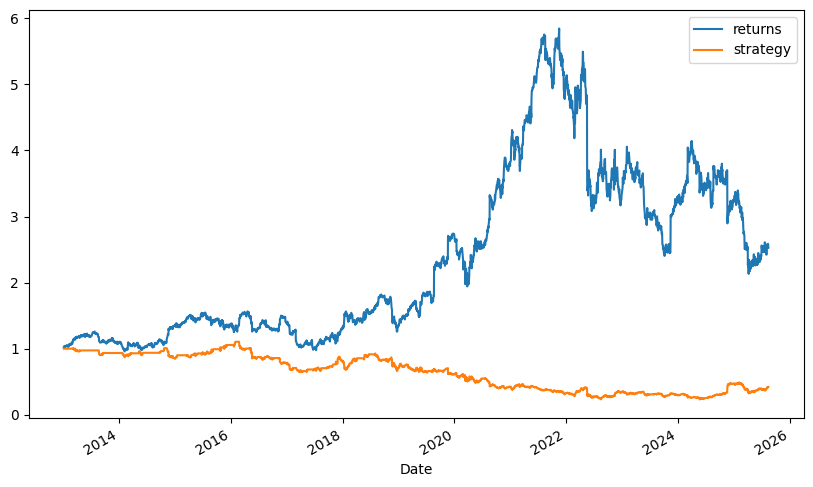

In [189]:
data[["returns", "strategy"]].dropna().cumsum().apply(np.exp).plot(figsize=(10, 6))